# Module 23: EDA + Baseline Model

This notebook performs data cleaning, feature engineering, exploratory data analysis, PCA inspection, and a baseline Logistic Regression model.


In [11]:
%pip install kagglehub pandas numpy seaborn matplotlib scikit-learn




[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob

try:
    import kagglehub
except ImportError:
    kagglehub = None

from collections import Counter
from itertools import product

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')



## 1) Download and load input files


In [13]:
def find_files(path, patterns):
    files = []
    for pat in patterns:
        files.extend(sorted(glob.glob(os.path.join(path, pat))))
    return files

def parse_fasta(filepath):
    rows = []
    header = None
    seq_parts = []
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith('>'):
                if header is not None and seq_parts:
                    rows.append({'sequence': ''.join(seq_parts), 'label': os.path.basename(filepath)})
                header = line[1:]
                seq_parts = []
            else:
                seq_parts.append(line)
    if header is not None and seq_parts:
        rows.append({'sequence': ''.join(seq_parts), 'label': os.path.basename(filepath)})
    return pd.DataFrame(rows)

def load_sequence_dir(seq_dir):
    csv_like = find_files(seq_dir, ['*.csv', '*.tsv'])
    txt_like = find_files(seq_dir, ['*.txt'])
    fasta_like = find_files(seq_dir, ['*.fa', '*.fasta'])

    parts = []
    for fp in csv_like:
        sep = '	' if fp.endswith('.tsv') else ','
        parts.append(pd.read_csv(fp, sep=sep))

    for fp in txt_like:
        # nageshsingh dataset stores tab-separated sequence/class files as .txt
        try:
            parts.append(pd.read_csv(fp, sep='	'))
        except Exception:
            pass

    for fp in fasta_like:
        parts.append(parse_fasta(fp))

    if not parts:
        raise FileNotFoundError(f'No supported files found in: {seq_dir}')

    df_seq = pd.concat(parts, ignore_index=True)

    # Prefer supervised rows when class labels are available
    if 'class' in df_seq.columns:
        labeled = df_seq['class'].notna()
        if labeled.any():
            df_seq = df_seq.loc[labeled].reset_index(drop=True)

    return df_seq

def first_classification_file(path):
    files = find_files(path, ['*.csv', '*.tsv', '*.txt'])
    if not files:
        raise FileNotFoundError(f'No tabular files found in: {path}')
    return files[0]

if kagglehub is not None:
    class_dir = kagglehub.dataset_download('miadul/dna-classification-dataset')
    seq_dir = kagglehub.dataset_download('nageshsingh/dna-sequence-dataset')
    print('Classification dataset folder:', class_dir)
    print('Sequence dataset folder:', seq_dir)

    classification_path = first_classification_file(class_dir)
    df_class = pd.read_csv(classification_path)
    df_seq = load_sequence_dir(seq_dir)
    sequence_path = seq_dir
else:
    # Fallback: manual local paths
    classification_path = '../data/raw/dna_classification.csv'
    sequence_path = '../data/raw/dna_sequence.csv'
    df_class = pd.read_csv(classification_path)
    df_seq = pd.read_csv(sequence_path)

print('Classification source:', classification_path)
print('Sequence source:', sequence_path)
print('Classification shape:', df_class.shape)
print('Sequence shape:', df_seq.shape)
print('Classification columns:', df_class.columns.tolist())
print('Sequence columns:', df_seq.columns.tolist())
display(df_class.head())
display(df_seq.head())



Classification dataset folder: /Users/bharadwajramachandran/.cache/kagglehub/datasets/miadul/dna-classification-dataset/versions/1
Sequence dataset folder: /Users/bharadwajramachandran/.cache/kagglehub/datasets/nageshsingh/dna-sequence-dataset/versions/1
Classification source: /Users/bharadwajramachandran/.cache/kagglehub/datasets/miadul/dna-classification-dataset/versions/1/synthetic_dna_dataset.csv
Sequence source: /Users/bharadwajramachandran/.cache/kagglehub/datasets/nageshsingh/dna-sequence-dataset/versions/1
Classification shape: (3000, 13)
Sequence shape: (6882, 3)
Classification columns: ['Sample_ID', 'Sequence', 'GC_Content', 'AT_Content', 'Sequence_Length', 'Num_A', 'Num_T', 'Num_C', 'Num_G', 'kmer_3_freq', 'Mutation_Flag', 'Class_Label', 'Disease_Risk']
Sequence columns: ['sequence', 'class', 'label']


,Sample_ID,Sequence,GC_Content,AT_Content,Sequence_Length,Num_A,Num_T,Num_C,Num_G,kmer_3_freq,Mutation_Flag,Class_Label,Disease_Risk
0,SAMPLE_1,CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCG...,50.0,50.0,100,22,28,19,31,0.986,0,Bacteria,High
1,SAMPLE_2,TTGACCAAATTTGATTGGAAGTGGTAAGCGCGTATTCCTAGCATCA...,45.0,55.0,100,27,28,22,23,0.486,1,Virus,Medium
2,SAMPLE_3,GCGTGAGTTCTAATTTAAAAAGTCGTAACACGTACCCCGGCGTGTA...,51.0,49.0,100,26,23,30,21,0.367,1,Bacteria,Low
3,SAMPLE_4,ACTACGCGGACAAGAACCAACAGAACCTGGTTTTCGCAAGGGAGTG...,55.0,45.0,100,28,17,23,32,0.404,0,Human,Medium
4,SAMPLE_5,TTCAATGCAGATTGAAAGTTACTTTCATCTGCCCTATGGGTCCCTT...,46.0,54.0,100,24,30,25,21,0.818,0,Human,High


,sequence,class,label
0,ATGCCCCAACTAAATACCGCCGTATGACCCACCATAATTACCCCCA...,4.0,NaN
1,ATGAACGAAAATCTATTCGCTTCATTCGCTGCCCCCACAATCCTAG...,4.0,NaN
2,ATGGCCTCGCGCTGGTGGCGGTGGCGACGCGGCTGCTCCTGGAGGC...,4.0,NaN
3,ATGGCCTCGCGCTGGTGGCGGTGGCGACGCGGCTGCTCCTGGAGGC...,4.0,NaN
4,ATGGGCAGCGCCAGCCCGGGTCTGAGCAGCGTGTCCCCCAGCCACC...,6.0,NaN


## 2) Harmonize schema and target
Set `sequence_col` and `target_col` based on your actual columns.


In [14]:
def best_sequence_target_columns(df):
    cols = list(df.columns)
    lower_map = {str(col).lower(): col for col in cols}

    seq_candidates = ['sequence', 'seq', 'dna_sequence']
    target_candidates = ['class', 'label', 'target']

    seq_options = [lower_map[c] for c in seq_candidates if c in lower_map]
    tgt_options = [lower_map[c] for c in target_candidates if c in lower_map]

    if not seq_options or not tgt_options:
        raise ValueError(f'Could not find expected sequence/target columns. Available: {cols}')

    sequence_col = max(seq_options, key=lambda col: df[col].notna().sum())

    scored = []
    for col in tgt_options:
        non_null = int(df[col].notna().sum())
        n_unique = int(df[col].dropna().nunique())
        scored.append((col, non_null, n_unique))

    valid = [t for t in scored if t[2] >= 2]
    if not valid:
        raise ValueError(f'No target column has at least 2 classes. Target stats: {scored}')

    target_col = sorted(valid, key=lambda t: (t[1], t[2]), reverse=True)[0][0]
    return sequence_col, target_col, scored

# Prefer nageshsingh sequence dataset as primary for modeling
df = df_seq.copy()

sequence_col, target_col, target_stats = best_sequence_target_columns(df)

if 'class' in df.columns and df['class'].dropna().nunique() >= 2:
    target_col = 'class'

print('Target candidate stats (col, non_null, n_unique):', target_stats)
print('Using sequence_col:', sequence_col)
print('Using target_col  :', target_col)

# Basic cleaning
df = df[[sequence_col, target_col]].copy()
df[sequence_col] = df[sequence_col].astype(str).str.upper().str.strip()
df = df.dropna(subset=[sequence_col, target_col]).drop_duplicates()
df = df[df[sequence_col].str.fullmatch(r'[ATCG]+', na=False)]

print('Cleaned shape:', df.shape)
print('Class counts after cleaning:')
print(df[target_col].value_counts().head(20))
display(df.head())



Target candidate stats (col, non_null, n_unique): [('class', 6882, 7), ('label', 0, 0)]
Using sequence_col: sequence
Using target_col  : class
Cleaned shape: (5708, 2)
Class counts after cleaning:
class
6.0    1753
4.0     898
3.0     831
0.0     769
1.0     633
2.0     467
5.0     357
Name: count, dtype: int64


,sequence,class
0,ATGCCCCAACTAAATACCGCCGTATGACCCACCATAATTACCCCCA...,4.0
1,ATGAACGAAAATCTATTCGCTTCATTCGCTGCCCCCACAATCCTAG...,4.0
2,ATGGCCTCGCGCTGGTGGCGGTGGCGACGCGGCTGCTCCTGGAGGC...,4.0
3,ATGGCCTCGCGCTGGTGGCGGTGGCGACGCGGCTGCTCCTGGAGGC...,4.0
4,ATGGGCAGCGCCAGCCCGGGTCTGAGCAGCGTGTCCCCCAGCCACC...,6.0


## 3) Feature engineering


In [15]:
K = 3
KMER_VOCAB = [''.join(p) for p in product('ATCG', repeat=K)]

def base_features(seq):
    seq = str(seq)
    n = len(seq)
    a = seq.count('A')
    t = seq.count('T')
    c = seq.count('C')
    g = seq.count('G')
    if n == 0:
        gc = np.nan
        at = np.nan
    else:
        gc = (g + c) / n
        at = (a + t) / n
    return pd.Series({
        'Num_A': float(a),
        'Num_T': float(t),
        'Num_C': float(c),
        'Num_G': float(g),
        'GC_Content': float(gc),
        'AT_Content': float(at),
        'Sequence_Length': float(n),
    })

def kmer_freqs(seq, k=K, vocab=KMER_VOCAB):
    seq = str(seq)
    total = max(len(seq) - k + 1, 0)
    counts = Counter(seq[i:i+k] for i in range(total)) if total > 0 else Counter()
    return pd.Series({f'kmer_{km}': (counts.get(km, 0) / total if total > 0 else 0.0) for km in vocab})

# Ensure contiguous index before feature assembly to avoid NaN from concat misalignment
df = df.reset_index(drop=True)
base_df = df[sequence_col].apply(base_features).reset_index(drop=True)
kmer_df = df[sequence_col].apply(kmer_freqs).reset_index(drop=True)

feat_df = pd.concat([df[[target_col]].reset_index(drop=True), base_df, kmer_df], axis=1)
feat_df = feat_df.dropna(subset=[target_col])
feature_cols = [c for c in feat_df.columns if c != target_col]
feat_df = feat_df.dropna(subset=feature_cols, how='all').reset_index(drop=True)

print('Feature dataframe shape:', feat_df.shape)
print('Any NaN in target:', feat_df[target_col].isna().any())
display(feat_df.head())



Feature dataframe shape: (5708, 72)
Any NaN in target: False


,class,Num_A,Num_T,Num_C,Num_G,GC_Content,AT_Content,Sequence_Length,kmer_AAA,kmer_AAT,...,kmer_GTC,kmer_GTG,kmer_GCA,kmer_GCT,kmer_GCC,kmer_GCG,kmer_GGA,kmer_GGT,kmer_GGC,kmer_GGG
0,4.0,79.0,45.0,69.0,14.0,0.400966,0.599034,207.0,0.097561,0.048780,...,0.004878,0.000000,0.000000,0.009756,0.014634,0.000000,0.000000,0.000000,0.000000,0.000000
1,4.0,204.0,179.0,224.0,74.0,0.437592,0.562408,681.0,0.017673,0.025037,...,0.005891,0.001473,0.016200,0.011782,0.020619,0.002946,0.002946,0.001473,0.010309,0.001473
2,4.0,353.0,302.0,287.0,306.0,0.475160,0.524840,1248.0,0.028090,0.018459,...,0.011236,0.013644,0.015249,0.016051,0.018459,0.012841,0.015249,0.013644,0.013644,0.010433
3,4.0,348.0,297.0,287.0,307.0,0.479419,0.520581,1239.0,0.028294,0.018593,...,0.010509,0.014551,0.015360,0.016977,0.019402,0.012935,0.014551,0.014551,0.013743,0.010509
4,6.0,202.0,163.0,321.0,322.0,0.637897,0.362103,1008.0,0.002982,0.002982,...,0.014911,0.023857,0.028827,0.024851,0.035785,0.014911,0.031809,0.011928,0.030815,0.028827


## 4) EDA


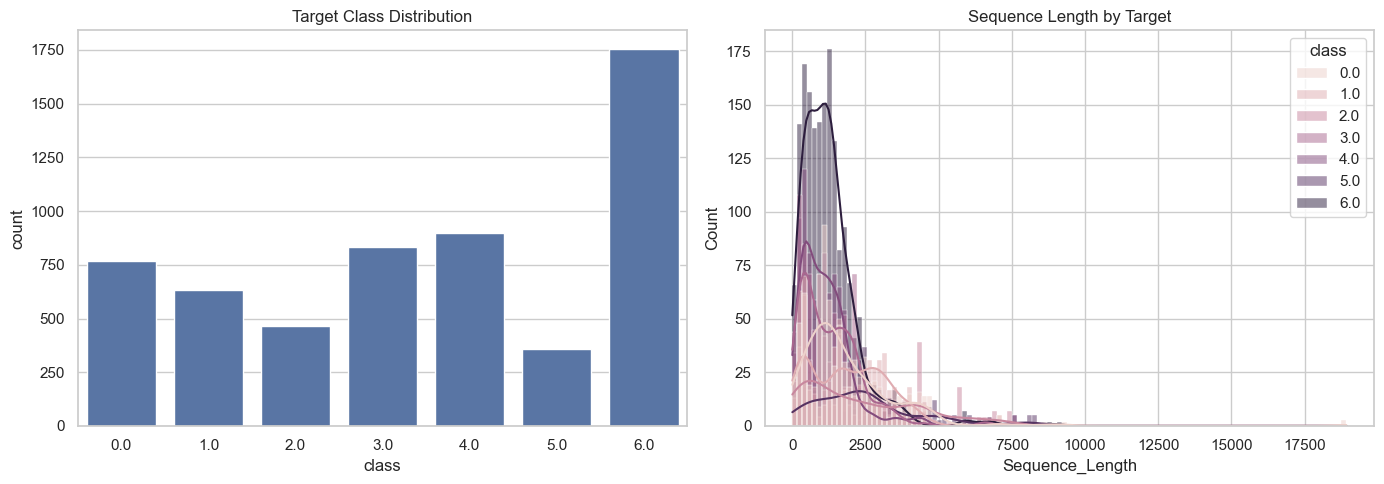

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=feat_df, x=target_col, ax=axes[0])
axes[0].set_title('Target Class Distribution')

sns.histplot(data=feat_df, x='Sequence_Length', hue=target_col, kde=True, ax=axes[1])
axes[1].set_title('Sequence Length by Target')
plt.tight_layout()
plt.show()



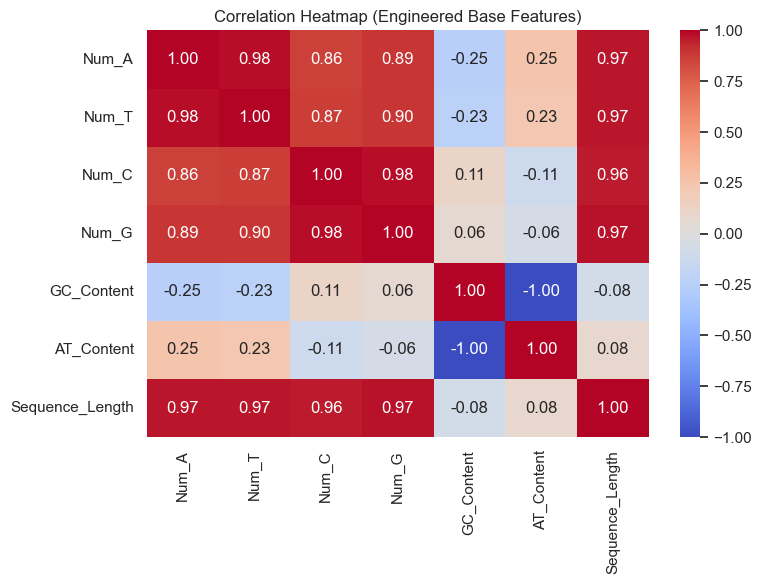

In [17]:
corr_cols = ['Num_A', 'Num_T', 'Num_C', 'Num_G', 'GC_Content', 'AT_Content', 'Sequence_Length']
plt.figure(figsize=(8, 6))
sns.heatmap(feat_df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Engineered Base Features)')
plt.tight_layout()
plt.show()



## 5) Outlier analysis (IQR rule)


,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
5,Num_C,151.000000,535.250000,384.250000,-425.375000,1111.625000,313,0.054835
6,Num_G,155.000000,534.000000,379.000000,-413.500000,1102.500000,308,0.053959
3,Num_A,136.000000,539.000000,403.000000,-468.500000,1143.500000,286,0.050105
4,Num_T,118.000000,473.250000,355.250000,-414.875000,1006.125000,265,0.046426
0,Sequence_Length,564.000000,2088.000000,1524.000000,-1722.000000,4374.000000,260,0.045550
2,AT_Content,0.399460,0.541734,0.142273,0.186051,0.755143,1,0.000175
1,GC_Content,0.458266,0.600540,0.142273,0.244857,0.813949,1,0.000175


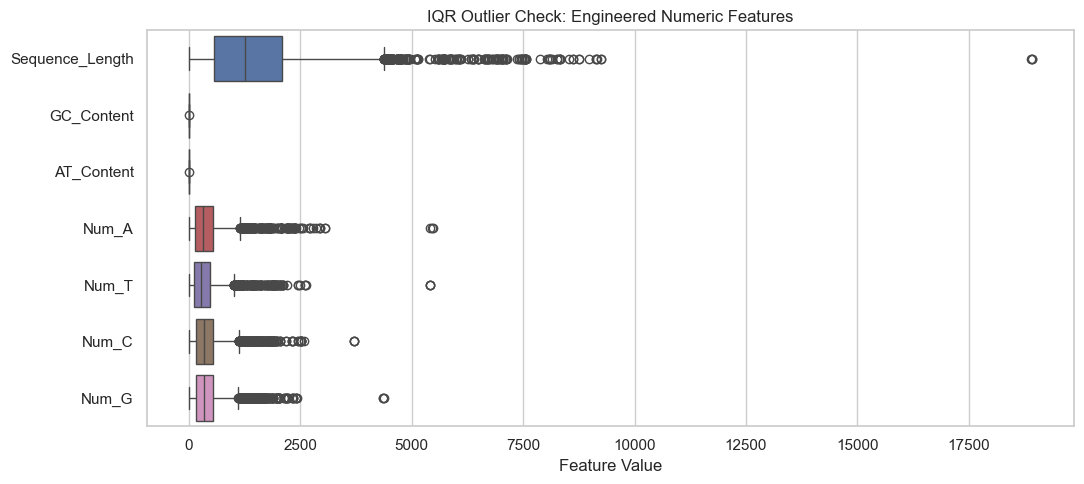

In [18]:
outlier_cols = ['Sequence_Length', 'GC_Content', 'AT_Content', 'Num_A', 'Num_T', 'Num_C', 'Num_G']
outlier_summary = []

for col in outlier_cols:
    q1 = feat_df[col].quantile(0.25)
    q3 = feat_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = int(((feat_df[col] < lower) | (feat_df[col] > upper)).sum())
    outlier_summary.append({
        'feature': col,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': n_out,
        'outlier_pct': n_out / len(feat_df) if len(feat_df) else np.nan,
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('outlier_count', ascending=False)
display(outlier_df)

plt.figure(figsize=(11, 5))
sns.boxplot(data=feat_df[outlier_cols], orient='h')
plt.title('IQR Outlier Check: Engineered Numeric Features')
plt.xlabel('Feature Value')
plt.tight_layout()
plt.show()



## 6) Train/test split and baseline Logistic Regression

**Metric choice rationale:** weighted F1 is treated as the primary score because class distributions may be imbalanced, and weighted F1 balances precision/recall while accounting for class support. Accuracy, weighted precision, weighted recall, and ROC-AUC (binary only) are also reported for context.


In [21]:
X = feat_df.drop(columns=[target_col])
y = feat_df[target_col]

valid_mask = (~y.isna()) & (~X.isna().all(axis=1))
X = X.loc[valid_mask].reset_index(drop=True)
y = y.loc[valid_mask].reset_index(drop=True)

n_classes = y.nunique()
class_counts = y.value_counts(dropna=False)
print('Class counts used for modeling:')
print(class_counts)

if n_classes < 2:
    print('Baseline model skipped: need at least 2 classes in target for classification.')
elif len(X) < 5 or class_counts.min() < 2:
    print('Baseline model skipped: insufficient samples per class for a stable stratified split.')
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    num_cols = X.columns.tolist()
    preprocess = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), num_cols)
        ]
    )

    clf = Pipeline([
        ('prep', preprocess),
        ('model', LogisticRegression(max_iter=2000, penalty='l2'))
    ])

    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, pred, average='weighted', zero_division=0)

    print('Primary metric (weighted F1):', round(f1, 4))
    print('Accuracy :', round(acc, 4))
    print('Precision:', round(prec, 4))
    print('Recall   :', round(rec, 4))
    print('F1 Score :', round(f1, 4))

    if n_classes == 2 and hasattr(clf, 'predict_proba'):
        proba = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba)
        print('ROC-AUC  :', round(auc, 4))

    print('Classification report:')
    print(classification_report(y_test, pred))



Class counts used for modeling:
class
6.0    1753
4.0     898
3.0     831
0.0     769
1.0     633
2.0     467
5.0     357
Name: count, dtype: int64
Primary metric (weighted F1): 0.6064
Accuracy : 0.6138
Precision: 0.6066
Recall   : 0.6138
F1 Score : 0.6064
Classification report:
              precision    recall  f1-score   support

         0.0       0.71      0.72      0.72       154
         1.0       0.56      0.49      0.52       127
         2.0       0.62      0.43      0.51        93
         3.0       0.45      0.49      0.47       166
         4.0       0.47      0.42      0.45       180
         5.0       0.56      0.45      0.50        71
         6.0       0.73      0.85      0.78       351

    accuracy                           0.61      1142
   macro avg       0.59      0.55      0.56      1142
weighted avg       0.61      0.61      0.61      1142



## 7) PCA quick check (~90% variance target)


Components for >=90% variance: 30
Explained variance at n90: 0.9039


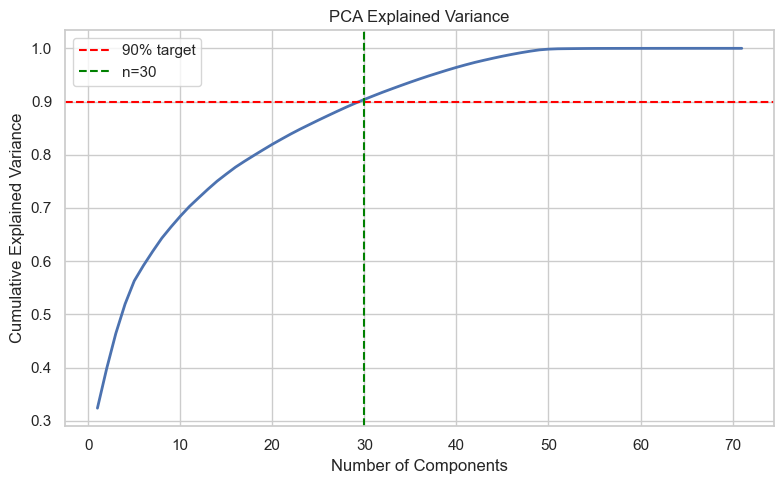

In [22]:
X_num = feat_df.drop(columns=[target_col]).copy()

# Keep only numeric columns for PCA and fill any residual NaN
X_num = X_num.select_dtypes(include=[np.number])
X_num = X_num.fillna(X_num.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

pca_full = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n90 = np.argmax(cum_var >= 0.90) + 1
print('Components for >=90% variance:', n90)
print('Explained variance at n90:', round(cum_var[n90 - 1], 4))

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var)+1), cum_var, linewidth=2)
plt.axhline(0.90, color='red', linestyle='--', label='90% target')
plt.axvline(n90, color='green', linestyle='--', label=f'n={n90}')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()



## 8) Notes for README update
After running this notebook, copy key values into `README.md` Results section.
